# When Does a Reservoir Bloom?

**Chlorophyll in the reservoirs of the Guadalquivir basin, with Sentinel-2**

A reservoir is not a uniform body of water. The tail, where the river comes in, is
shallow, warm and carries the nutrients the catchment washes down; the water by the dam
is deeper, colder and older. So the algae do not bloom everywhere at once — and the
question this notebook asks is **when** each part of a reservoir reaches its maximum
chlorophyll, not how much it has.

The measurement is NDCI, the Normalized Difference Chlorophyll Index, which uses the red
edge band that only Sentinel-2 carries. The timing comes from `get_peak_period()`, the
same call that maps the month of peak greenness in a forest or the brightest night of a
city — here pointed at the water.

Two things have to be right before the timing means anything:

1. **NDCI is only interpretable over water.** On land it is just another band ratio, and
   a reservoir's shoreline moves every month, so the mask has to be built from the data
   rather than from the reservoir's nominal outline.
2. **The peak of a noisy series is not a peak.** A single cloudy month can win, so the
   notebook checks how many months tie and how far the maximum stands above the rest.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 2. The reservoirs

The outlines come from a public Earth Engine asset: the reservoirs of the
**Confederación Hidrográfica del Guadalquivir** (CHG), the basin authority for southern
Spain, uploaded as a FeatureCollection so the notebook runs without any local file.

In [2]:
CHG = 'projects/ee-digdgeografo/assets/CHG_CaptacionesEmbalses'

reservoirs = (ee.FeatureCollection(CHG)
              .map(lambda f: f.set('area_km2', f.geometry().area(10).divide(1e6))))

largest = reservoirs.sort('area_km2', False).limit(8)
pd.DataFrame([{'name': f['properties']['Nombre'],
               'km²': round(f['properties']['area_km2'], 1)}
              for f in largest.getInfo()['features']]).set_index('name')

,km²
name,
Iznájar,24.4
Puente Nuevo,20.2
Encinarejo,15.4
Melonares,14.6
Guadalén,14.3
Guadalmena,13.4
Bembézar,11.8
Huesna,11.3


In [3]:
NAME = 'Iznájar'          # the largest reservoir in Andalusia
YEARS = (2020, 2025)

reservoir = reservoirs.filter(ee.Filter.eq('Nombre', NAME)).first().geometry()
roi = reservoir.buffer(300)   # a margin, so the shoreline is inside the composite

print(f'{NAME}: {reservoir.area(10).divide(1e6).getInfo():.1f} km²')

Iznájar: 24.4 km²


## 3. Where there is water every month

The reservoir outline is the *maximum* extent, filled to the brim. Real water covers less
than that and moves with the season and the year, so the analysis is restricted to the
pixels that are water in **every** month of the series — the permanent pool. Those are
the only pixels where a chlorophyll series has the same meaning in January and in August.

MNDWI (Xu 2006) does the detection: it uses green and SWIR, and holds up better than NDWI
where there is vegetation around the shore.

In [4]:
water = NdviSeasonality(roi=roi, sat='S2', index='mndwi', key='median', periods=12,
                        start_year=YEARS[0], end_year=YEARS[1])

# One image per year, twelve bands each: collapse the years into the typical year
mndwi = water.get_year_composite().median()

is_water = mndwi.gt(0)                       # twelve binary bands
months_wet = is_water.reduce(ee.Reducer.sum())
permanent = months_wet.eq(12).selfMask()     # water in all twelve months

area = lambda img: (img.multiply(ee.Image.pixelArea()).divide(1e6)
                    .reduceRegion(ee.Reducer.sum(), roi, 20, maxPixels=1e9)
                    .values().get(0).getInfo())

print(f'permanent water: {area(permanent.unmask(0)):.2f} km²')
print(f'water in July:   {area(is_water.select("july")):.2f} km²')
print(f'water in March:  {area(is_water.select("march")):.2f} km²')

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 12/12 periods with data using mndwi index


Year 2021: 12/12 periods with data using mndwi index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using mndwi index


Year 2023: 12/12 periods with data using mndwi index


No data for period 3 (march) in year 2024, filled with a masked band
No data for period 10 (october) in year 2024, filled with a masked band
Year 2024: 10/12 periods with data using mndwi index


Year 2025: 12/12 periods with data using mndwi index


permanent water: 8.39 km²


water in July:   10.44 km²


water in March:  12.04 km²


Iznájar holds **8.4 km² of permanent water**, against the 24.4 km² of its outline. The
outline is the reservoir full to the crest; the water that is actually there every month
of 2020-2025 covers a third of it. Working from the polygon instead of from the data
would have put two thirds of the "reservoir" on dry land, where NDCI means nothing.

Note also that March has *more* water than July — 12.0 against 10.4 km². The reservoir
fills with the winter rains and is drawn down through the irrigation season, so its
shoreline is a moving target, which is the whole reason the analysis is restricted to
the pixels that are wet in all twelve months.

## 4. Chlorophyll over the water

NDCI compares the red edge band (B5, 705 nm) with red: chlorophyll reflects the first and
absorbs the second, so the index rises with algal concentration. Values above ~0.1 are
usually read as a productive bloom in inland waters (Mishra & Mishra, 2012).

The composites are built exactly like the water ones — monthly medians across six
years — and then masked to the permanent pool.

In [5]:
chl = NdviSeasonality(roi=roi, sat='S2', index='ndci', key='median', periods=12,
                      start_year=YEARS[0], end_year=YEARS[1])

ndci = chl.get_year_composite().median().updateMask(permanent)

monthly = ndci.reduceRegion(ee.Reducer.mean(), roi, 20, maxPixels=1e9).getInfo()
series = pd.Series({m: monthly[m] for m in chl.period_names}, name='NDCI')
series.round(3).to_frame().T

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 12/12 periods with data using ndci index


Year 2021: 12/12 periods with data using ndci index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using ndci index


Year 2023: 12/12 periods with data using ndci index


No data for period 3 (march) in year 2024, filled with a masked band
No data for period 10 (october) in year 2024, filled with a masked band
Year 2024: 10/12 periods with data using ndci index


Year 2025: 12/12 periods with data using ndci index


,january,february,march,april,may,june,july,august,september,october,november,december
NDCI,-0.365,-0.19,-0.138,-0.111,-0.026,-0.007,-0.01,-0.022,-0.091,-0.084,-0.382,-0.251


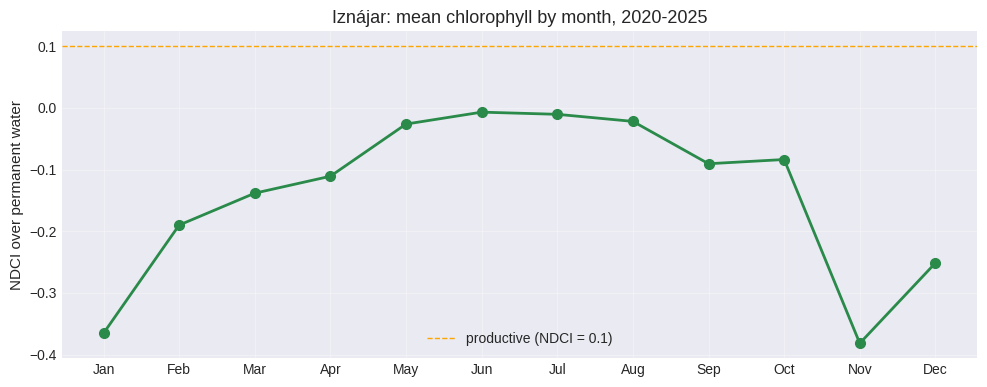

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 13), series.values, 'o-', color='#2a8a4a', linewidth=2)
ax.axhline(0.1, color='orange', ls='--', lw=1, label='productive (NDCI = 0.1)')
ax.set_xticks(range(1, 13), [m[:3].capitalize() for m in chl.period_names])
ax.set_ylabel('NDCI over permanent water')
ax.set_title(f'{NAME}: mean chlorophyll by month, {YEARS[0]}-{YEARS[1]}')
ax.legend(frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

Every month is negative, from −0.38 in November to −0.01 in July. NDCI above ~0.1 is the
usual threshold for a productive bloom, so **Iznájar is not blooming**: this is a
comparatively clear, oligotrophic reservoir, and what follows is the timing of a *relative*
maximum, not of an algal crisis. That distinction matters — the method answers "when is
this pixel at its highest", and the answer exists whether or not the highest is high.

The shape is the expected one for a Mediterranean reservoir: a minimum in late autumn,
when the rains bring cold turbid water in, and a plateau from May to August, when the
water is warm and stratified.

## 5. The month of the peak, pixel by pixel

The curve above is the whole reservoir averaged into one number per month. It hides
exactly what we are after: whether the tail and the dam peak at the same time.

`get_peak_period()` answers that per pixel. The `composite=` argument is what makes it
usable here — the peak is taken from the composite **already masked to water**, instead
of being recomputed from scratch over land and water alike.

In [7]:
peak = chl.get_peak_period(composite=ndci, return_peak_value=True, return_ties=True)

counts = {m: peak.select('peak_period').eq(i + 1).selfMask()
             .reduceRegion(ee.Reducer.count(), roi, 20, maxPixels=1e9)
             .getInfo()['peak_period']
          for i, m in enumerate(chl.period_names)}
pd.Series(counts, name='pixels peaking').to_frame().T

,january,february,march,april,may,june,july,august,september,october,november,december
pixels peaking,0,130,128,2486,1654,9203,8664,2297,219,1341,77,209


In [8]:
ties = peak.select('ties').reduceRegion(ee.Reducer.mean(), roi, 20,
                                        maxPixels=1e9).getInfo()['ties']
above = peak.select('peak_value').reduceRegion(ee.Reducer.mean(), roi, 20,
                                               maxPixels=1e9).getInfo()['peak_value']
print(f'mean number of months tied at the maximum: {ties:.3f}')
print(f'mean NDCI at the peak: {above:.3f}  (annual mean: {series.mean():.3f})')

mean number of months tied at the maximum: 1.000
mean NDCI at the peak: 0.029  (annual mean: -0.140)


**June and July hold the peak of nearly 70% of the water pixels**, with April and May
behind them. The average pixel has its maximum at NDCI 0.029, against an annual mean of
−0.140: the peak stands well clear of the rest of the year, so this is a real seasonal
signal and not a coin flip between twelve similar months.

And **no ties at all** — a mean of exactly 1.000 months tied. NDCI is a continuous ratio,
so two months landing on precisely the same value would be a coincidence. Compare that
with a count, where ties are the norm.

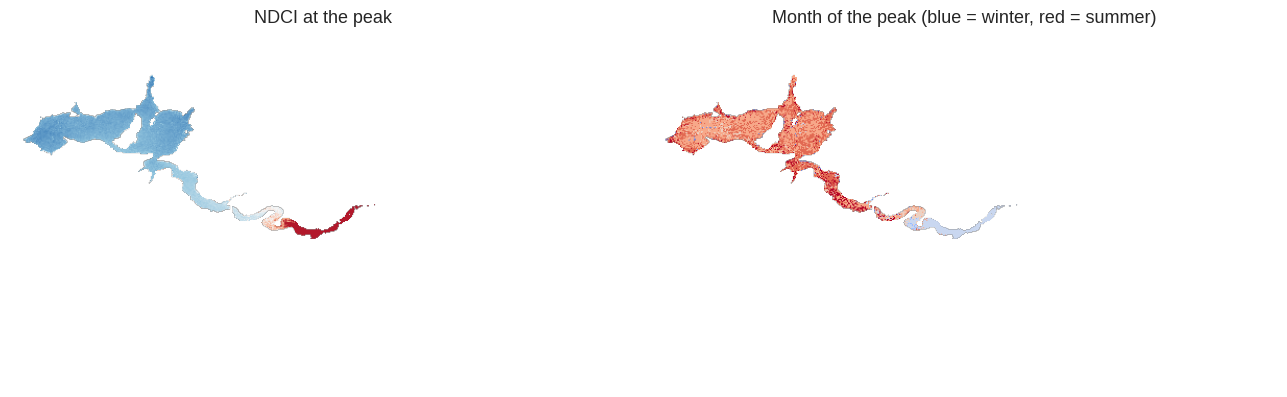

In [9]:
def thumbnail(image, vis, region, dimensions=600):
    url = image.visualize(**vis).getThumbURL(
        {'region': region, 'dimensions': dimensions, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))

month_vis = {'min': 1, 'max': 12,
             'palette': ['#3b4cc0', '#6788ee', '#9abbff', '#c9d7f0', '#edd1c2',
                         '#f7a889', '#e26952', '#b40426', '#e26952', '#f7a889',
                         '#c9d7f0', '#6788ee']}
ndci_vis = {'min': -0.1, 'max': 0.3,
            'palette': ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#b2182b']}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(thumbnail(peak.select('peak_value'), ndci_vis, roi))
axes[0].set_title('NDCI at the peak')
axes[1].imshow(thumbnail(peak.select('peak_period'), month_vis, roi))
axes[1].set_title('Month of the peak (blue = winter, red = summer)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

The left map is the chlorophyll at the peak and the right one is when that peak happens.
The second is the useful one: it is not uniform. The arms and the shallow edges carry
different timing from the open water, which is the gradient the next section measures.

## 6. Open water and shallow arms

A reservoir fills a valley, so the obvious idea is to use elevation: the tail sits
upstream where the riverbed was higher, the dam closes the deepest point. It does not
work, and the reason is worth keeping.

SRTM flew in **February 2000**, and Iznájar was closed in **1969**. Radar does not see
through water, so what the DEM holds over this reservoir is the surface of the
reservoir — a flat 396 m, with the same value at the 25th and the 75th percentile. The
drowned valley is not in there. (It would be, for a reservoir built *after* the DEM was
made, which is the sort of accident that makes a method work in one place and silently
fail in another.)

What does work is the geometry of the water itself. The shallow arms where the rivers
come in are narrow, so every pixel in them is close to a shore; the main body by the dam
is wide, so its centre is far from any shore. Distance to the shoreline is therefore a
usable proxy for the limnological gradient — the riverine, nutrient-rich, warm end
against the deep lacustrine end — and it comes from the water mask, with no extra data.

In [10]:
SCALE, CRS = 20, 'EPSG:25830'

# Distance from each water pixel to the nearest non-water pixel. The transform
# needs a fixed projection: a composite carries none, and the distance would
# otherwise be measured on whatever grid the request happens to use
water01 = permanent.unmask(0).reproject(crs=CRS, scale=SCALE)

# fastDistanceTransform measures the distance to the nearest NON-ZERO pixel,
# so it has to run on the land mask: run on the water it returns zero
# everywhere inside the water, which is exactly where we need the distance
to_shore = (water01.Not().fastDistanceTransform(256).sqrt().multiply(SCALE)
            .updateMask(permanent).rename('to_shore'))

cuts = to_shore.reduceRegion(ee.Reducer.percentile([25, 75]), roi, SCALE,
                             maxPixels=1e9).getInfo()
near, far = cuts['to_shore_p25'], cuts['to_shore_p75']
print(f'distance to the shore: {near:.0f} m (p25) to {far:.0f} m (p75)')

zones = {'shallow arms (nearest quarter to a shore)': to_shore.lte(near),
         'open water (farthest quarter from any shore)': to_shore.gte(far)}

rows = []
for label, mask in zones.items():
    zone = peak.updateMask(mask)
    share = {m: zone.select('peak_period').eq(i + 1).selfMask()
                .reduceRegion(ee.Reducer.count(), roi, SCALE, maxPixels=1e9)
                .getInfo()['peak_period']
             for i, m in enumerate(chl.period_names)}
    total = sum(share.values()) or 1
    rows.append(pd.Series({m: v / total for m, v in share.items()}, name=label))

zone_table = pd.DataFrame(rows)
zone_table.style.format('{:.0%}').background_gradient(cmap='Greens', axis=1)

distance to the shore: 57 m (p25) to 234 m (p75)


,january,february,march,april,may,june,july,august,september,october,november,december
shallow arms (nearest quarter to a shore),0%,2%,1%,21%,7%,15%,23%,13%,3%,14%,1%,1%
open water (farthest quarter from any shore),0%,0%,0%,0%,5%,53%,38%,1%,0%,1%,0%,1%


In [11]:
# The same split, read as a single number: the mean month of the peak
weights = np.arange(1, 13)
for label, row in zone_table.iterrows():
    mean_month = float((row.values * weights).sum())
    print(f'{label:48s} mean peak month = {mean_month:.2f}')

shallow arms (nearest quarter to a shore)        mean peak month = 6.67
open water (farthest quarter from any shore)     mean peak month = 6.48


The prediction going in was that the shallow arms would peak **earlier**: shallower, fed
directly by the rivers, quicker to warm. They do not. The mean peak month is 6.67 in the
arms against 6.48 in the open water — if anything a fortnight later, which is well inside
the noise. That hypothesis is simply not supported here.

What the table does show is a difference of a different kind: **not when, but how
tightly**.

The open water is emphatic. Ninety-one per cent of its pixels peak in June or July (53%
and 38%), and essentially none outside them. A deep, well-mixed body follows the thermal
cycle and nothing else, so every pixel of it does the same thing at the same time.

The shallow arms are scattered: 23% in July, 21% in April, 15% in June, 14% in October.
They respond to what their own river brings — a flood, a turbid pulse, an irrigation
release — and those events do not share a calendar. The arms are not early, they are
**individually driven**.

That is a more useful result than the one expected, because it says where an average
misleads. A reservoir-wide monthly mean is a fair summary of the open water and a poor
one of the arms, and the arms are precisely where a bloom tends to start.

## 7. The same question across reservoirs

One reservoir is an anecdote. The same three calls over the largest reservoirs of the
basin say whether the timing is a property of this valley or of the region's climate.

In [12]:
def peak_month_of(name, years=YEARS):
    """Modal month of the chlorophyll peak over a reservoir's permanent water."""
    geom = reservoirs.filter(ee.Filter.eq('Nombre', name)).first().geometry()
    area = geom.buffer(300)

    w = NdviSeasonality(roi=area, sat='S2', index='mndwi', key='median', periods=12,
                        start_year=years[0], end_year=years[1])
    pool = w.get_year_composite().median().gt(0).reduce(ee.Reducer.sum()).eq(12).selfMask()

    c = NdviSeasonality(roi=area, sat='S2', index='ndci', key='median', periods=12,
                        start_year=years[0], end_year=years[1])
    masked = c.get_year_composite().median().updateMask(pool)
    p = c.get_peak_period(composite=masked)

    counts = {m: p.eq(i + 1).selfMask()
                 .reduceRegion(ee.Reducer.count(), area, 20, maxPixels=1e9)
                 .getInfo()['peak_period']
              for i, m in enumerate(c.period_names)}
    total = sum(counts.values()) or 1
    best = max(counts, key=counts.get)
    return {'reservoir': name, 'peak month': best,
            'share of pixels': counts[best] / total, 'water pixels': total}

names = ['Iznájar', 'Puente Nuevo', 'Encinarejo', 'Melonares', 'Guadalén']
pd.DataFrame([peak_month_of(n) for n in names]).set_index('reservoir')

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 12/12 periods with data using mndwi index


Year 2021: 12/12 periods with data using mndwi index


No data for period 3 (march) in year 2022, filled with a masked band
No data for period 4 (april) in year 2022, filled with a masked band
Year 2022: 10/12 periods with data using mndwi index


Year 2023: 12/12 periods with data using mndwi index


...

No data for period 11 (november) in year 2022, filled with a masked band
Year 2022: 11/12 periods with data using ndci index


Year 2023: 12/12 periods with data using ndci index


No data for period 3 (march) in year 2024, filled with a masked band
Year 2024: 11/12 periods with data using ndci index


Year 2025: 12/12 periods with data using ndci index


,peak month,share of pixels,water pixels
reservoir,,,
Iznájar,june,0.348493,26408
Puente Nuevo,august,0.534627,20620
Encinarejo,august,0.813972,7558
Melonares,april,0.288396,31533
Guadalén,may,0.292103,11181


Five reservoirs in the same basin, under the same climate, peaking in **four different
months**: Iznájar in June, Melonares in April, Guadalén in May, and Puente Nuevo and
Encinarejo in August. If the timing were driven by regional weather alone they would
move together. They do not, so what sets the date is local: depth, residence time, the
catchment upstream and how the dam is operated.

Note how the concentration varies too. Encinarejo gives August 81% of its pixels — a
small reservoir behaving as one body — while Iznájar spreads its June over a third of
them, which is what a large reservoir with distinct arms looks like. The share of pixels
is as informative as the month.

## 8. Taking the maps out

`peak_period` is a small single-band image, so it exports in seconds and opens in any
GIS. The values are month numbers, and `period_names` is the legend.

In [13]:
task = ee.batch.Export.image.toDrive(
    image=peak.select(['peak_period', 'peak_value']).toFloat(),
    description=f'{NAME}_chlorophyll_peak',
    folder='ndvi2gif',
    region=roi,
    scale=20,
    crs='EPSG:25830',
    maxPixels=1e9,
)
# task.start()      # uncomment to launch it
print('band 1 = month of the peak:',
      dict(enumerate(chl.period_names, start=1)))

band 1 = month of the peak: {1: 'january', 2: 'february', 3: 'march', 4: 'april', 5: 'may', 6: 'june', 7: 'july', 8: 'august', 9: 'september', 10: 'october', 11: 'november', 12: 'december'}


## 9. What to take away

**Build the mask from the data, not from the outline.** Iznájar's polygon is two thirds
dry. Any index averaged over that polygon is a mixture of water and shore, and the
mixture changes with the season, which is enough to invent a cycle that is not there.

**A peak is not a bloom.** Every monthly NDCI here is negative. `get_peak_period()`
answers *when*, and it answers it just as confidently on a clear reservoir as on a
eutrophic one — so the timing map should always be read next to the values, which is what
`return_peak_value=True` is for.

**The inside of a reservoir is not uniform, but not in the way expected.** The shallow
arms do not peak earlier than the open water; they peak *less predictably*, spread across
four months where the open body concentrates 91% of itself into two. Worth remembering
before averaging a reservoir into one number.

**Check that your proxy measures what you think.** The elevation split failed silently:
SRTM flew in 2000, the reservoir closed in 1969, and the DEM holds the water surface, not
the valley floor. It returned two identical quartiles and two identical answers — an
error that announces itself only if you look at the intermediate numbers. The replacement,
distance to the shoreline, had a trap of its own: `fastDistanceTransform` measures the
distance to the nearest *non-zero* pixel, so it has to be run on the land mask, not the
water one.

**Timing is local.** Five reservoirs under one climate peak in four different months. A
basin-wide average would have hidden every one of them.